IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load dataset

In [2]:
df = pd.read_csv("ecommerce.csv")

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Region,City,Category,Sub_Category,Product_Name,Quantity,Price,Discount,Payment_Mode,Shipping_Cost,Profit
0,ORD100001,2025-01-16,10161,Vikram Shah,East,Kolkata,Home & Kitchen,Home Decor,Table Lamp,2,2278.00,5.0,Card,445.94,1198.51
1,ORD100002,2025-10-29,10039,Pooja Patel,North,Chandigarh,Sports,Team Sports,Football,1,1497.34,5.0,Card,293.55,-76.13
2,ORD100003,2025-03-06,10389,Nikhil Joshi,West,Pune,Electronics,Wearables,Smart Watch,1,3549.50,5.0,UPI,154.45,922.11
3,ORD100004,2025-11-01,10399,Pooja Kumar,North,Delhi,Sports,Fitness,Yoga Mat,1,661.77,20.0,COD,138.77,-18.61
4,ORD100005,2025-11-29,10062,Ananya Sharma,West,Ahmedabad,Sports,Team Sports,Football,5,1466.36,0.0,Card,381.89,1964.67


In [4]:
df.shape

(1005, 15)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Region',
       'City', 'Category', 'Sub_Category', 'Product_Name', 'Quantity', 'Price',
       'Discount', 'Payment_Mode', 'Shipping_Cost', 'Profit'],
      dtype='object')

Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1005 non-null   object 
 1   Order_Date     1005 non-null   object 
 2   Customer_ID    1005 non-null   int64  
 3   Customer_Name  1005 non-null   object 
 4   Region         1005 non-null   object 
 5   City           997 non-null    object 
 6   Category       1005 non-null   object 
 7   Sub_Category   1005 non-null   object 
 8   Product_Name   1005 non-null   object 
 9   Quantity       1005 non-null   int64  
 10  Price          1005 non-null   float64
 11  Discount       997 non-null    float64
 12  Payment_Mode   1005 non-null   object 
 13  Shipping_Cost  1005 non-null   float64
 14  Profit         1005 non-null   float64
dtypes: float64(4), int64(2), object(9)
memory usage: 117.9+ KB


In [7]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Region,0
City,8
Category,0
Sub_Category,0
Product_Name,0
Quantity,0


In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
df.describe()

,Customer_ID,Quantity,Price,Discount,Shipping_Cost,Profit
count,1005.000000,1005.000000,1005.000000,997.000000,1005.000000,1005.000000
mean,10328.115423,2.025871,9257.462040,8.269809,231.974836,3782.269881
std,184.232462,1.160148,18280.199619,6.941409,119.068407,9398.589860
min,10001.000000,1.000000,205.920000,0.000000,30.080000,-371.330000
25%,10174.000000,1.000000,1497.340000,5.000000,128.950000,296.320000
50%,10333.000000,2.000000,2864.200000,5.000000,227.050000,835.140000
75%,10489.000000,3.000000,5369.780000,10.000000,334.310000,2338.210000
max,10650.000000,5.000000,89957.230000,25.000000,449.000000,107834.890000


Data cleaning

In [10]:
df_clean = df.copy()

In [11]:
df_clean['Discount'] = df_clean['Discount'].fillna(0)

In [12]:
df_clean['Discount'].isnull().sum()

np.int64(0)

In [13]:
df_clean['City'] = df_clean['City'].fillna('Unknown')

In [14]:
df_clean['City'].isnull().sum()

np.int64(0)

In [15]:
df_clean = df_clean.drop_duplicates()

In [16]:
df_clean.shape

(1000, 15)

In [17]:
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'])

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   int64         
 3   Customer_Name  1000 non-null   object        
 4   Region         1000 non-null   object        
 5   City           1000 non-null   object        
 6   Category       1000 non-null   object        
 7   Sub_Category   1000 non-null   object        
 8   Product_Name   1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Price          1000 non-null   float64       
 11  Discount       1000 non-null   float64       
 12  Payment_Mode   1000 non-null   object        
 13  Shipping_Cost  1000 non-null   float64       
 14  Profit         1000 non-null   float64       
dtypes: datetime64[ns](1), float

In [19]:
df_clean['Revenue'] = (
    df_clean['Quantity'] *
    df_clean['Price'] *
    (1 - df_clean['Discount'] / 100)
)

In [20]:
df_clean[['Quantity', 'Price', 'Discount', 'Revenue']].head()

,Quantity,Price,Discount,Revenue
0,2,2278.00,5.0,4328.200
1,1,1497.34,5.0,1422.473
2,1,3549.50,5.0,3372.025
3,1,661.77,20.0,529.416
4,5,1466.36,0.0,7331.800


In [21]:
df_clean['Month'] = df_clean['Order_Date'].dt.month

In [22]:
df_clean[['Order_Date', 'Month']].head()

,Order_Date,Month
0,2025-01-16,1
1,2025-10-29,10
2,2025-03-06,3
3,2025-11-01,11
4,2025-11-29,11


In [23]:
df_clean.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Region,0
City,0
Category,0
Sub_Category,0
Product_Name,0
Quantity,0


In [24]:
df_clean.shape

(1000, 17)

4. Exploratory Data Analysis (EDA)

4.1 Total Revenue

In [26]:
total_revenue = df_clean['Revenue'].sum()
total_revenue

np.float64(16162378.951)

In [27]:
total_profit = df_clean['Profit'].sum()
total_profit

np.float64(3732846.37)

In [28]:
total_orders = df_clean['Order_ID'].nunique()
total_orders

1000

In [29]:
average_order_value = total_revenue / total_orders
average_order_value

np.float64(16162.378950999999)

In [30]:
print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 16162378.95
Total Profit: 3732846.37
Total Orders: 1000
Average Order Value: 16162.38


In [31]:
top_products = (
    df_clean.groupby('Product_Name')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Revenue
Product_Name,
Laptop,8.456306e+06
Mobile Phone,2.810206e+06
Smart Watch,7.299653e+05
Air Fryer,4.598320e+05
Bluetooth Speaker,4.593053e+05
Wireless Earbuds,3.729070e+05
Jacket,3.503790e+05
Mixer Grinder,3.386182e+05
Sneakers,3.207551e+05


In [32]:
region_sales = (
    df_clean.groupby('Region')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

region_sales

,Revenue
Region,
West,5.484395e+06
North,4.233126e+06
East,3.703478e+06
South,2.741380e+06


In [33]:
category_sales = (
    df_clean.groupby('Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Revenue
Category,
Electronics,1.282869e+07
Home & Kitchen,1.381672e+06
Clothing,1.033129e+06
Sports,6.115809e+05
Beauty,3.073073e+05


In [34]:
monthly_sales = (
    df_clean.groupby('Month')['Revenue']
    .sum()
    .sort_index()
)

monthly_sales

,Revenue
Month,
1,1.385774e+06
2,1.122698e+06
3,1.141945e+06
4,1.774479e+06
5,1.348279e+06
6,1.616706e+06
7,1.393053e+06
8,1.113060e+06
9,1.529897e+06


In [36]:
customer_orders = df_clean['Customer_ID'].value_counts()

repeat_customers = customer_orders[customer_orders > 1]

repeat_customers.head(10)

,count
Customer_ID,
10439,7
10566,7
10161,6
10071,6
10069,6
10550,5
10495,5
10334,5
10480,5


In [37]:
number_of_repeat_customers = len(repeat_customers)

print("Total Repeat Customers:", number_of_repeat_customers)

Total Repeat Customers: 286


In [38]:
repeat_customer_percentage = (
    number_of_repeat_customers / df_clean['Customer_ID'].nunique()
) * 100

print("Repeat Customer Percentage:",
      round(repeat_customer_percentage, 2), "%")

Repeat Customer Percentage: 55.75 %


In [40]:
payment_orders = df_clean['Payment_Mode'].value_counts()

payment_orders

,count
Payment_Mode,
UPI,359
Card,319
COD,215
Net Banking,107


In [41]:
payment_revenue = (
    df_clean.groupby('Payment_Mode')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

,Revenue
Payment_Mode,
UPI,6.106185e+06
Card,5.852380e+06
COD,2.804390e+06
Net Banking,1.399423e+06


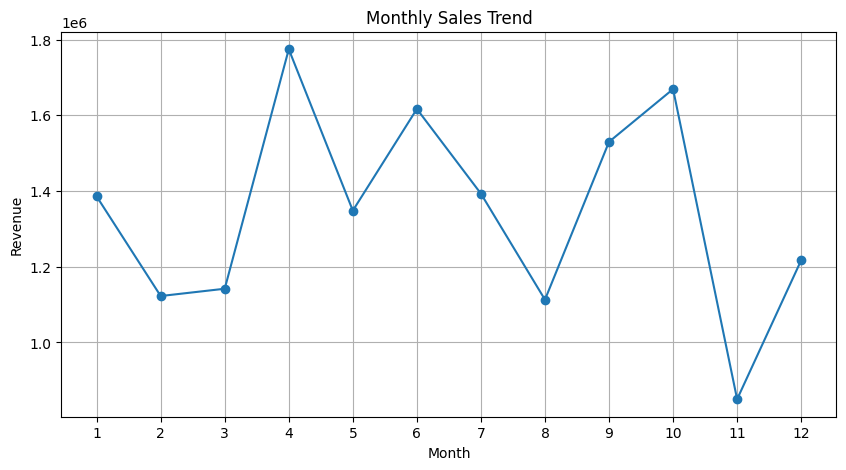

In [42]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

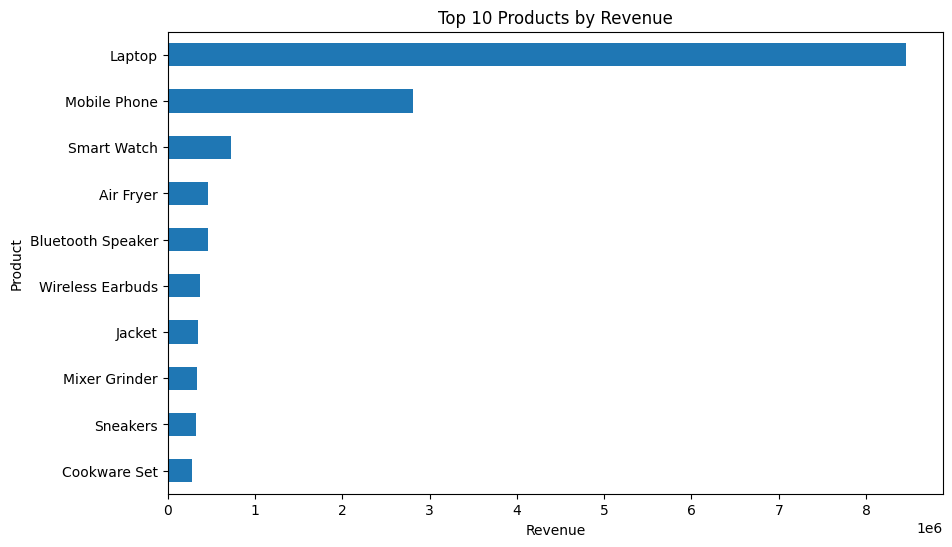

In [43]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

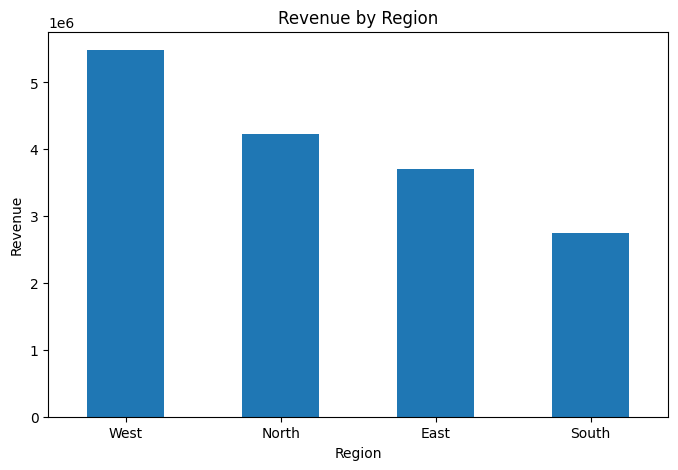

In [44]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.show()

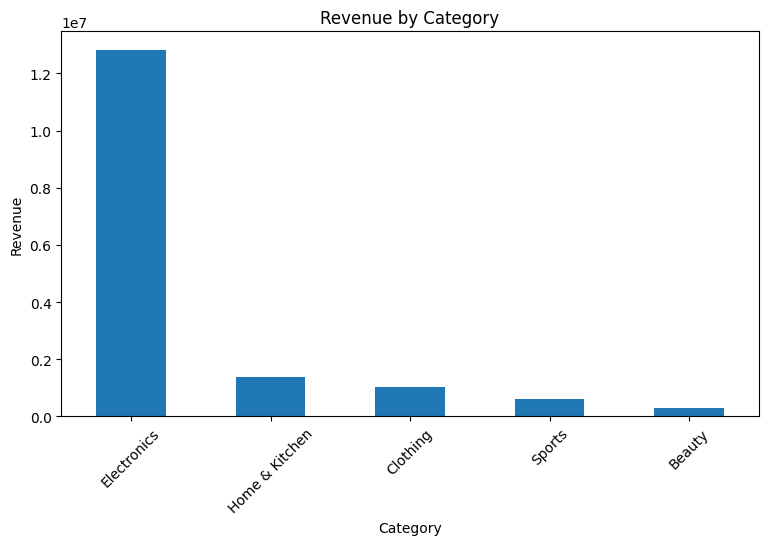

In [45]:
plt.figure(figsize=(9, 5))

category_sales.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

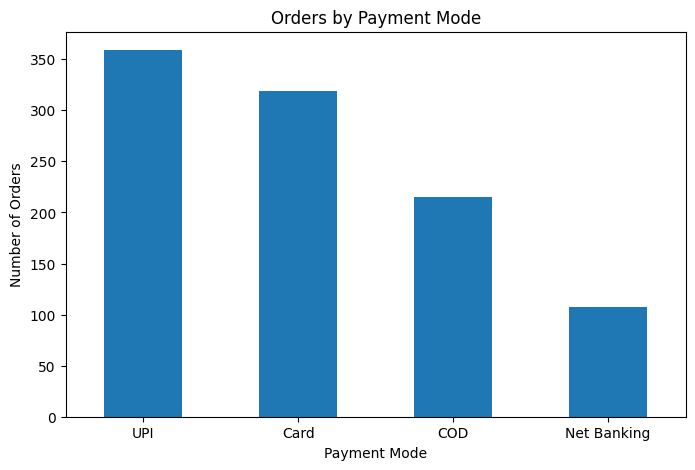

In [46]:
plt.figure(figsize=(8, 5))

payment_orders.plot(kind='bar')

plt.title('Orders by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.show()

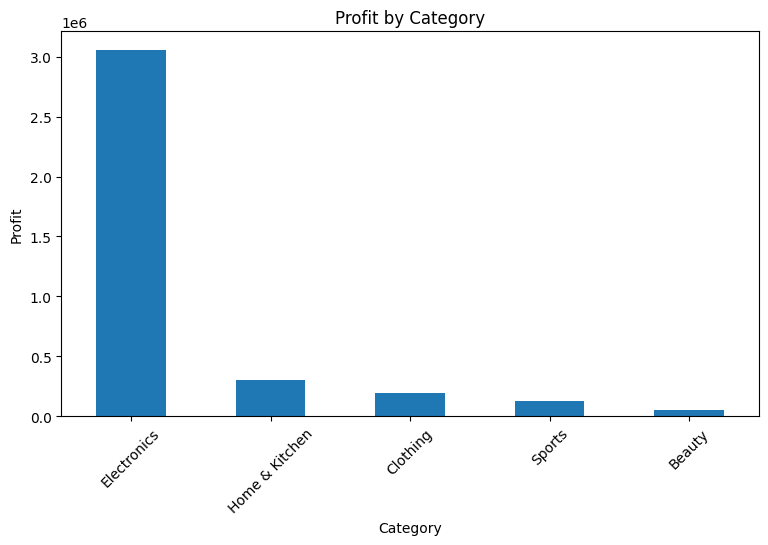

In [47]:
profit_by_category = (
    df_clean.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

profit_by_category.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)

plt.show()

## 5. Business Insights

In [48]:
# Best performing region
best_region = region_sales.idxmax()
best_region_revenue = region_sales.max()

# Best performing category
best_category = category_sales.idxmax()
best_category_revenue = category_sales.max()

# Lowest performing category
lowest_category = category_sales.idxmin()
lowest_category_revenue = category_sales.min()

# Best selling product
best_product = top_products.idxmax()
best_product_revenue = top_products.max()

# Best payment mode by number of orders
most_used_payment = payment_orders.idxmax()
most_used_payment_orders = payment_orders.max()

# Highest revenue payment mode
highest_revenue_payment = payment_revenue.idxmax()
highest_payment_revenue = payment_revenue.max()

# Best sales month
best_month = monthly_sales.idxmax()
best_month_revenue = monthly_sales.max()

print("BUSINESS INSIGHTS")
print("-" * 40)

print(f"Best Region: {best_region}")
print(f"Best Region Revenue: {best_region_revenue:,.2f}")

print(f"\nBest Category: {best_category}")
print(f"Best Category Revenue: {best_category_revenue:,.2f}")

print(f"\nLowest Performing Category: {lowest_category}")
print(f"Lowest Category Revenue: {lowest_category_revenue:,.2f}")

print(f"\nTop Product: {best_product}")
print(f"Top Product Revenue: {best_product_revenue:,.2f}")

print(f"\nMost Used Payment Mode: {most_used_payment}")
print(f"Orders: {most_used_payment_orders}")

print(f"\nHighest Revenue Payment Mode: {highest_revenue_payment}")
print(f"Revenue: {highest_payment_revenue:,.2f}")

print(f"\nBest Sales Month: {best_month}")
print(f"Revenue: {best_month_revenue:,.2f}")

print(f"\nRepeat Customer Percentage: {repeat_customer_percentage:.2f}%")

BUSINESS INSIGHTS
----------------------------------------
Best Region: West
Best Region Revenue: 5,484,395.49

Best Category: Electronics
Best Category Revenue: 12,828,689.73

Lowest Performing Category: Beauty
Lowest Category Revenue: 307,307.33

Top Product: Laptop
Top Product Revenue: 8,456,305.97

Most Used Payment Mode: UPI
Orders: 359

Highest Revenue Payment Mode: UPI
Revenue: 6,106,185.21

Best Sales Month: 4
Revenue: 1,774,479.31

Repeat Customer Percentage: 55.75%


In [49]:
df_clean.to_csv('ecommerce_cleaned.csv', index=False)